In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/sample_submission.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/train.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv


In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv')

train.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


In [3]:
train.describe()
train.isnull().sum()
train.duplicated().sum()

train = train.drop_duplicates()

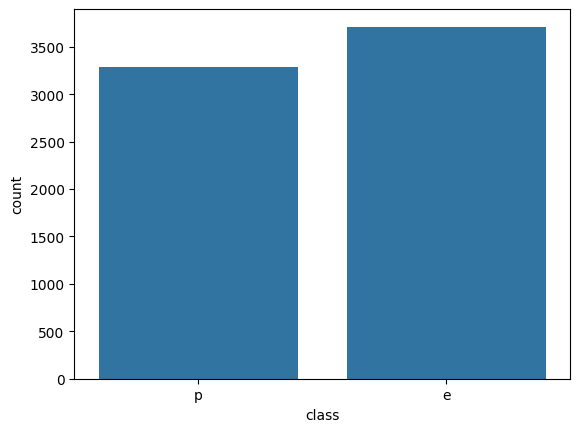

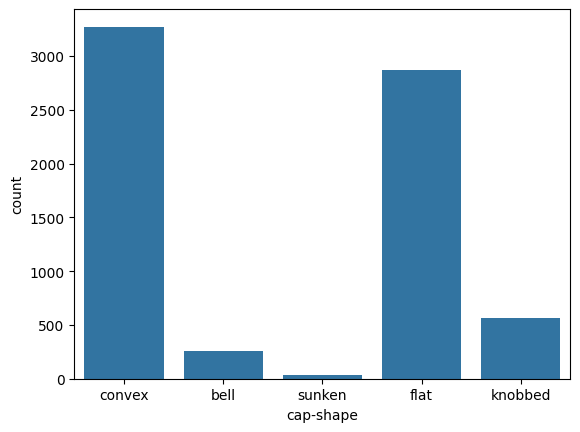

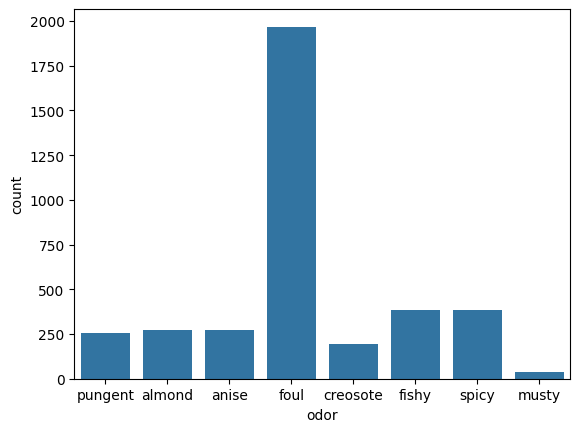

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train['class'])
plt.show()

sns.countplot(x=train['cap-shape'])
plt.show()

sns.countplot(x=train['odor'])
plt.show()

In [5]:
from sklearn.preprocessing import OrdinalEncoder

X = train.drop(['class', 'ID', 'mushroom_id'], axis=1)
y = train['class']

# convert target
y = y.map({'e': 0, 'p': 1})

test_X = test.drop(['ID', 'mushroom_id'], axis=1)

# ONE encoder for everything (IMPORTANT)
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X = encoder.fit_transform(X)
test_X = encoder.transform(test_X)

# 🔥 ADD THIS (VERY IMPORTANT FIX)
X = np.nan_to_num(X)
test_X = np.nan_to_num(test_X)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(n_estimators=200, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(name, "Accuracy:", acc)

Logistic Accuracy: 0.9942857142857143
DecisionTree Accuracy: 1.0
RandomForest Accuracy: 1.0
GradientBoost Accuracy: 1.0
KNN Accuracy: 0.9957142857142857
SVM Accuracy: 0.995
XGBoost Accuracy: 1.0


In [8]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(n_estimators=200, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(name, "Accuracy:", acc)

Logistic Accuracy: 0.9942857142857143
DecisionTree Accuracy: 1.0
RandomForest Accuracy: 1.0
GradientBoost Accuracy: 1.0
KNN Accuracy: 0.9957142857142857
SVM Accuracy: 0.995
XGBoost Accuracy: 1.0


In [9]:
best_model = XGBClassifier(n_estimators=300, eval_metric='logloss')
best_model.fit(X, y)

final_preds = best_model.predict(test_X)

sample = pd.read_csv('/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/sample_submission.csv')

submission = sample.copy()
submission['class'] = pd.Series(final_preds).map({0: 'e', 1: 'p'})

submission.to_csv('submission.csv', index=False)